# 08 — Modélisation : Random Forest

**Objectif** : entraîner et optimiser une forêt aléatoire pour la détection d'anomalies CBC, sur les deux configurations de features (Expérience A : 9 features, Expérience B1 : 5 features).

**Principe** : Random Forest combine de nombreux Decision Trees entraînés sur des échantillons bootstrap différents (bagging) et avec un sous-ensemble aléatoire de variables à chaque division (feature randomness), puis agrège leurs prédictions par vote majoritaire. Cela réduit la variance par rapport à un arbre unique (étape 7), tout en conservant sa capacité à capturer des règles par seuils.

**Hypothèse à vérifier** : Random Forest devrait au moins égaler le Decision Tree optimisé, avec une meilleure généralisation attendue sur l'Expérience B1.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import time
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from evaluation import evaluate_model, plot_confusion_matrices, results_table

os.makedirs('../models', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

RANDOM_STATE = 42

## 0. Chargement des données préparées (issues de l'étape 4)

In [2]:
X_train_A = pd.read_csv('../data/processed/X_train_A.csv')
X_test_A  = pd.read_csv('../data/processed/X_test_A.csv')
y_train_A = pd.read_csv('../data/processed/y_train_A.csv').squeeze()
y_test_A  = pd.read_csv('../data/processed/y_test_A.csv').squeeze()

X_train_B1 = pd.read_csv('../data/processed/X_train_B1.csv')
X_test_B1  = pd.read_csv('../data/processed/X_test_B1.csv')
y_train_B1 = pd.read_csv('../data/processed/y_train_B1.csv').squeeze()
y_test_B1  = pd.read_csv('../data/processed/y_test_B1.csv').squeeze()

print("Expérience A :", X_train_A.shape, X_test_A.shape)
print("Expérience B1:", X_train_B1.shape, X_test_B1.shape)

Expérience A : (419075, 9) (104769, 9)
Expérience B1: (419075, 5) (104769, 5)


## 1. Baseline — Random Forest avec paramètres par défaut (100 arbres)

In [3]:
rf_A_baseline = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
model_A_base, y_pred_A_base, metrics_A_base = evaluate_model(
    rf_A_baseline, X_train_A, y_train_A, X_test_A, y_test_A,
    "RF baseline - Exp A"
)

rf_B1_baseline = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
model_B1_base, y_pred_B1_base, metrics_B1_base = evaluate_model(
    rf_B1_baseline, X_train_B1, y_train_B1, X_test_B1, y_test_B1,
    "RF baseline - Exp B1"
)

results_table([metrics_A_base, metrics_B1_base])

,Modèle,Accuracy,Precision,Recall,F1-score,Temps (s)
0,RF baseline - Exp A,0.998836,0.998864,0.997065,0.997964,42.22
1,RF baseline - Exp B1,0.844410,0.748945,0.686477,0.716351,46.22


## 2. Recherche d'hyperparamètres — GridSearchCV (Expérience A)

Grille testée :
- `n_estimators` : nombre d'arbres dans la forêt
- `max_depth` : profondeur max de chaque arbre
- `min_samples_split` / `min_samples_leaf` : régularisation
- `max_features` : nombre de variables considérées à chaque division

⚠️ Note : la grille est volontairement plus compacte que pour Decision Tree, car chaque combinaison entraîne `n_estimators` arbres au lieu d'un seul — le temps de calcul total augmente vite.

In [6]:
param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt']
}

grid_rf_A = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=3,                 # cv réduit à 3 (au lieu de 5) pour limiter le temps de calcul
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_rf_A.fit(X_train_A, y_train_A)
print(f"Temps de recherche: {time.time()-start:.1f}s")

print("\nMeilleurs paramètres (Exp A):", grid_rf_A.best_params_)
print("Meilleur F1-score (CV, Exp A):", grid_rf_A.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Temps de recherche: 1011.6s

Meilleurs paramètres (Exp A): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Meilleur F1-score (CV, Exp A): 0.9975708897972618


## 3. Recherche d'hyperparamètres — GridSearchCV (Expérience B1)

In [7]:
grid_rf_B1 = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_rf_B1.fit(X_train_B1, y_train_B1)
print(f"Temps de recherche: {time.time()-start:.1f}s")

print("\nMeilleurs paramètres (Exp B1):", grid_rf_B1.best_params_)
print("Meilleur F1-score (CV, Exp B1):", grid_rf_B1.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Temps de recherche: 870.9s

Meilleurs paramètres (Exp B1): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Meilleur F1-score (CV, Exp B1): 0.7178953813778611


## 4. Évaluation finale des meilleurs modèles sur le TEST set

In [14]:
best_rf_A = grid_rf_A.best_estimator_
best_rf_B1 = grid_rf_B1.best_estimator_

y_pred_A = best_rf_A.predict(X_test_A)
y_pred_B1 = best_rf_B1.predict(X_test_B1)

results = []
for name, y_true, y_pred in [
    ("RF baseline - Exp A", y_test_A, y_pred_A_base),
    ("RF optimisé - Exp A", y_test_A, y_pred_A),
    ("RF baseline - Exp B1", y_test_B1, y_pred_B1_base),
    ("RF optimisé - Exp B1", y_test_B1, y_pred_B1),
]:
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
    })

df_results = results_table(results)
df_results

,Modèle,Accuracy,Precision,Recall,F1-score
0,RF baseline - Exp A,0.998836,0.998864,0.997065,0.997964
1,RF optimisé - Exp A,0.998836,0.998864,0.997065,0.997964
2,RF baseline - Exp B1,0.844410,0.748945,0.686477,0.716351
3,RF optimisé - Exp B1,0.847426,0.759586,0.683108,0.719320


## 5. Matrices de confusion (baseline vs optimisé, A vs B1)

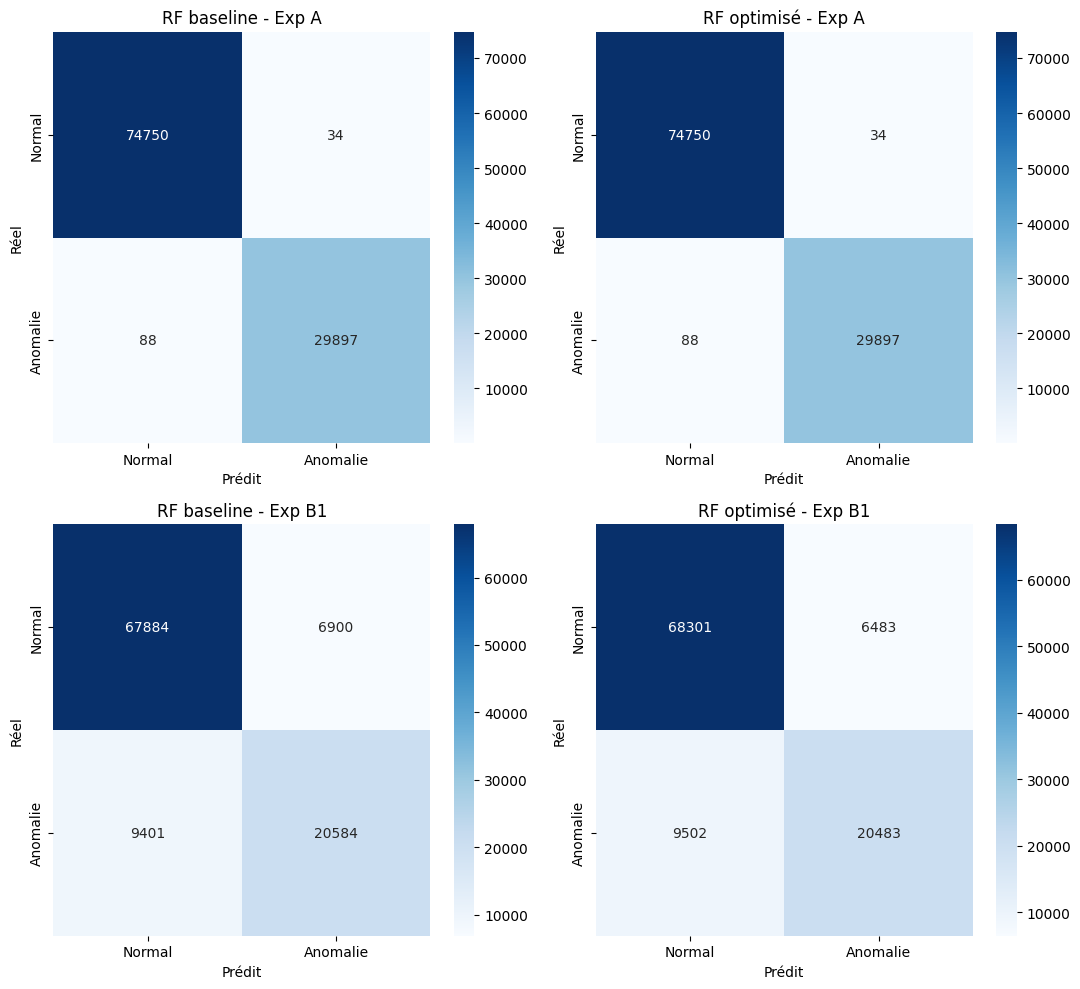

In [15]:
configs = [
    (y_test_A, y_pred_A_base, "RF baseline - Exp A"),
    (y_test_A, y_pred_A, "RF optimisé - Exp A"),
    (y_test_B1, y_pred_B1_base, "RF baseline - Exp B1"),
    (y_test_B1, y_pred_B1, "RF optimisé - Exp B1"),
]

plot_confusion_matrices(configs, save_path='../figures/confusion_matrices_rf.png')

## 6. Importance des variables (moyennée sur tous les arbres de la forêt)

Plus stable/fiable que celle d'un Decision Tree unique, car moyennée sur des centaines d'arbres entraînés sur des sous-échantillons différents.

In [16]:
importance_A = pd.DataFrame({
    'Variable': X_train_A.columns,
    'Importance': best_rf_A.feature_importances_
}).sort_values('Importance', ascending=False)

importance_B1 = pd.DataFrame({
    'Variable': X_train_B1.columns,
    'Importance': best_rf_B1.feature_importances_
}).sort_values('Importance', ascending=False)

print("Importance des variables (Expérience A):")
print(importance_A)
print("\nImportance des variables (Expérience B1):")
print(importance_B1)

Importance des variables (Expérience A):
  Variable  Importance
3       HB    0.196748
2    LEUKO    0.177012
4      PLT    0.164416
1       HK    0.152235
0      ERY    0.111798
6     MCHC    0.058963
5      MCV    0.050946
7      MCH    0.047965
8      RDW    0.039918

Importance des variables (Expérience B1):
  Variable  Importance
0       HK    0.499774
4      RDW    0.148741
1      MCV    0.133407
2     MCHC    0.121195
3      MCH    0.096883


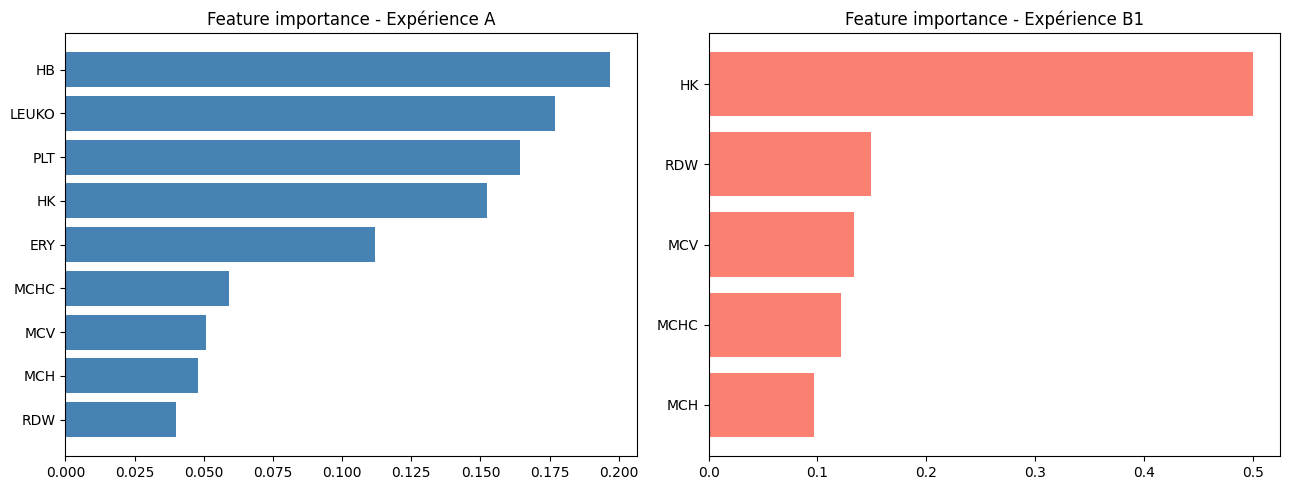

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(importance_A['Variable'], importance_A['Importance'], color='steelblue')
axes[0].set_title('Feature importance - Expérience A')
axes[0].invert_yaxis()

axes[1].barh(importance_B1['Variable'], importance_B1['Importance'], color='salmon')
axes[1].set_title('Feature importance - Expérience B1')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../figures/feature_importance_rf.png', dpi=150)
plt.show()

## 7. Comparaison directe Decision Tree vs Random Forest

On recharge les résultats du Decision Tree (étape 7) pour comparer directement l'apport du Random Forest.

In [18]:
try:
    df_results_dt = pd.read_csv('../data/processed/results_dt.csv')
    comparison = pd.concat([
        df_results_dt[df_results_dt['Modèle'].str.contains('optimisé')],
        df_results[df_results['Modèle'].str.contains('optimisé')]
    ], ignore_index=True)
    print("Comparaison Decision Tree (optimisé) vs Random Forest (optimisé):")
    comparison
except FileNotFoundError:
    print("⚠️ results_dt.csv non trouvé — exécutez d'abord le notebook 07 (Decision Tree)")

Comparaison Decision Tree (optimisé) vs Random Forest (optimisé):


## 8. Sauvegarde des modèles et résultats

In [19]:
joblib.dump(best_rf_A, '../models/rf_A_best.pkl')
joblib.dump(best_rf_B1, '../models/rf_B1_best.pkl')

df_results.to_csv('../data/processed/results_rf.csv', index=False)
print("✅ Modèles et résultats Random Forest sauvegardés")

✅ Modèles et résultats Random Forest sauvegardés


## Ce qu'il faut analyser pour le rapport

1. **RF vs Decision Tree** : Random Forest a-t-il amélioré le F1-score par rapport au Decision Tree seul, en particulier sur l'Expérience B1 (où la réduction de variance devrait le plus aider) ?
2. **`n_estimators` retenu** : 100 ou 200 arbres ont-ils fait une différence notable, ou les gains sont-ils marginaux (rendements décroissants) ?
3. **Feature importance** : cohérence avec le Decision Tree et avec la pondération médicale de l'étape 3 — Random Forest donne généralement une estimation plus stable.
4. **Temps de calcul** : noter l'écart de temps d'entraînement avec Decision Tree (RF est plus lent, normal puisqu'il entraîne des centaines d'arbres) — un compromis performance/coût à mentionner dans la conclusion.